#Set up library

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

#Load data

In [65]:
df = pd.read_csv('calories.csv')
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


#EDA

In [66]:
df.shape

(15000, 9)

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [68]:
df.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [69]:
num_cols = df.select_dtypes(include=['number'])
cat_cols = df.select_dtypes(include=['object'])
num_cols, cat_cols

(        User_ID  Age  Height  Weight  Duration  Heart_Rate  Body_Temp  \
 0      14733363   68   190.0    94.0      29.0       105.0       40.8   
 1      14861698   20   166.0    60.0      14.0        94.0       40.3   
 2      11179863   69   179.0    79.0       5.0        88.0       38.7   
 3      16180408   34   179.0    71.0      13.0       100.0       40.5   
 4      17771927   27   154.0    58.0      10.0        81.0       39.8   
 ...         ...  ...     ...     ...       ...         ...        ...   
 14995  15644082   20   193.0    86.0      11.0        92.0       40.4   
 14996  17212577   27   165.0    65.0       6.0        85.0       39.2   
 14997  17271188   43   159.0    58.0      16.0        90.0       40.1   
 14998  18643037   78   193.0    97.0       2.0        84.0       38.3   
 14999  11751526   63   173.0    79.0      18.0        92.0       40.5   
 
        Calories  
 0         231.0  
 1          66.0  
 2          26.0  
 3          71.0  
 4          35.

##Univariate analysis

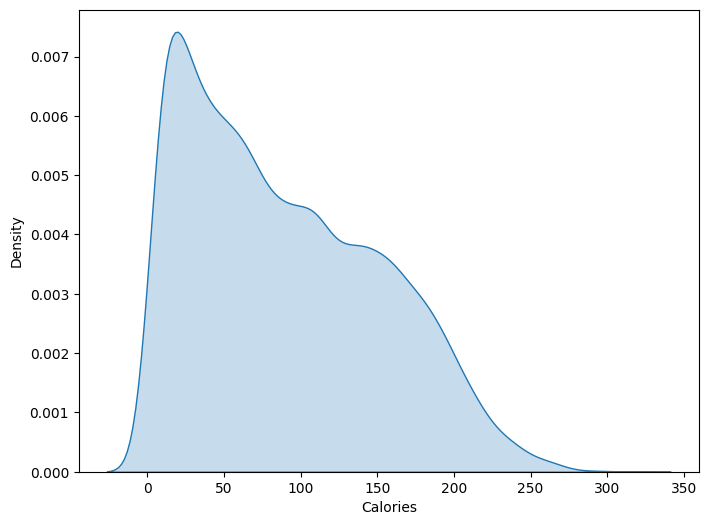

In [70]:
plt.figure(figsize=(8, 6))
sns.kdeplot(x='Calories', data=df, fill=True)
plt.show()

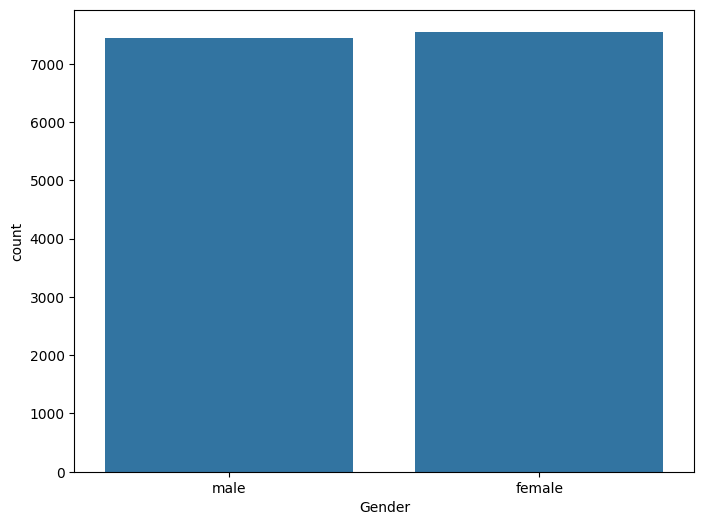

In [71]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Gender')
plt.show()

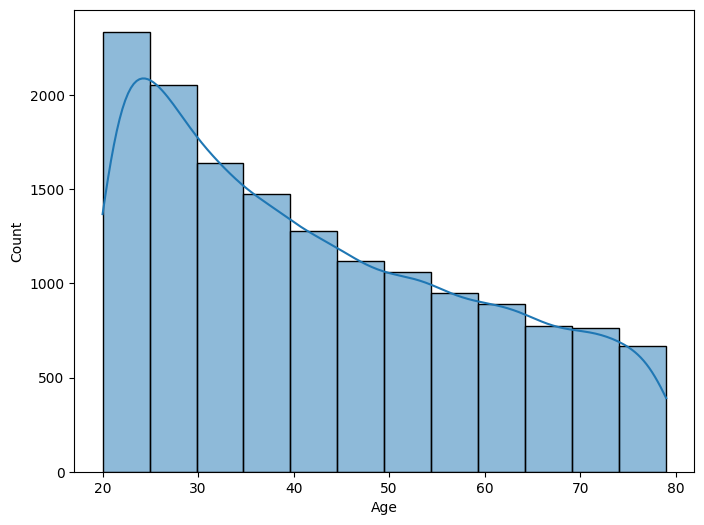

In [72]:
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='Age', bins=12, kde=True, fill=True)
plt.show()

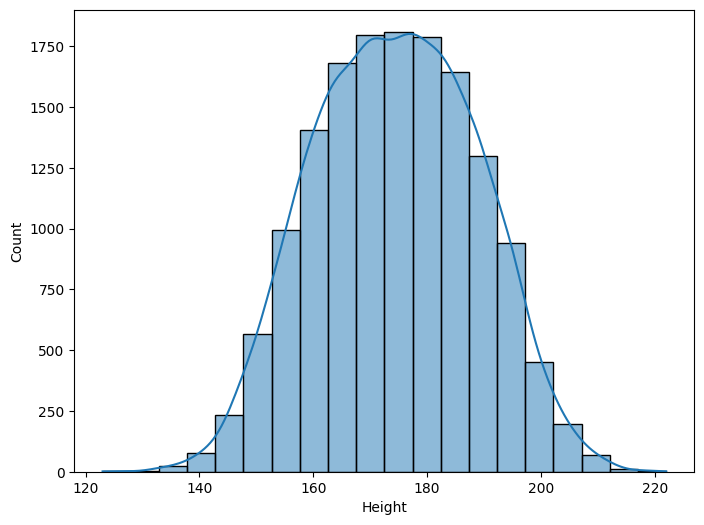

In [73]:
plt.figure(figsize=(8, 6))
sns.histplot(x='Height', data=df, bins=20, kde=True)
plt.show()

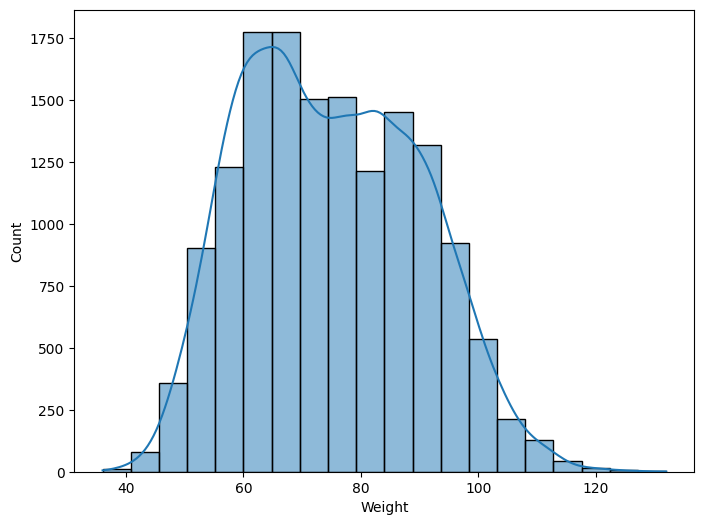

In [74]:
plt.figure(figsize=(8, 6))
sns.histplot(x='Weight', data=df, bins=20, kde=True)
plt.show()

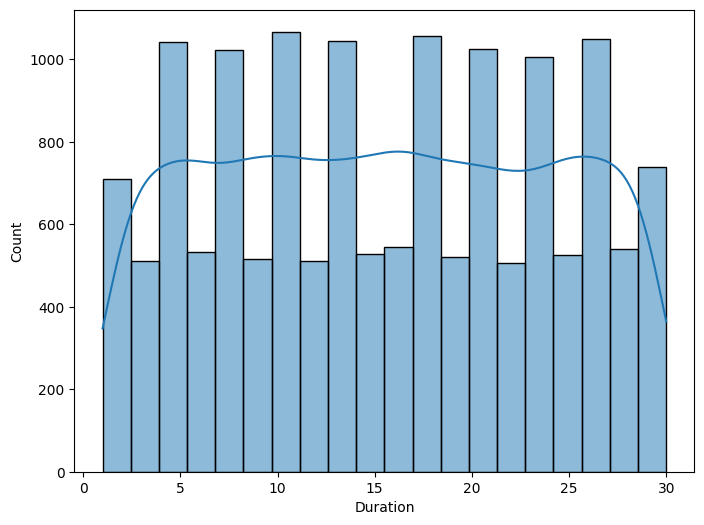

In [75]:
plt.figure(figsize=(8, 6))
sns.histplot(x='Duration', data=df, bins=20, kde=True)
plt.show()

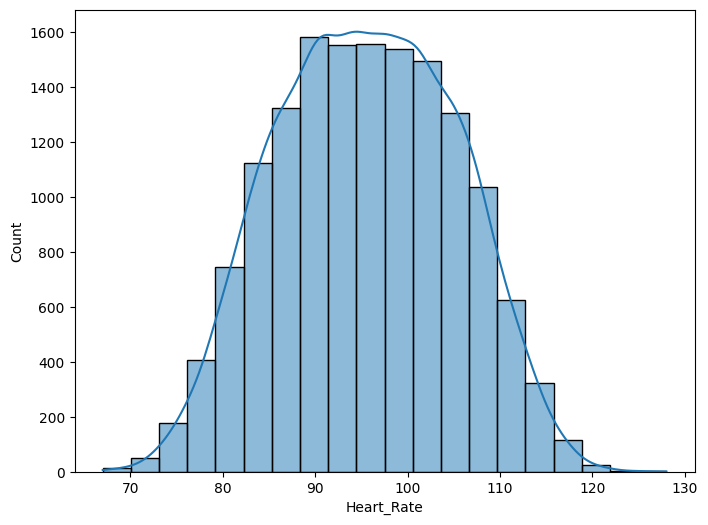

In [76]:
plt.figure(figsize=(8, 6))
sns.histplot(x='Heart_Rate', data=df, bins=20, kde=True)
plt.show()

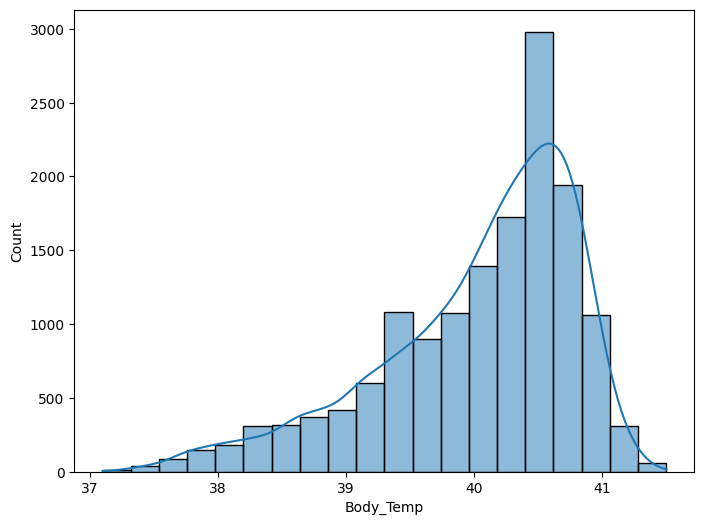

In [77]:
plt.figure(figsize=(8, 6))
sns.histplot(x='Body_Temp', data=df, bins=20, kde=True)
plt.show()

##Multivariate Analysis

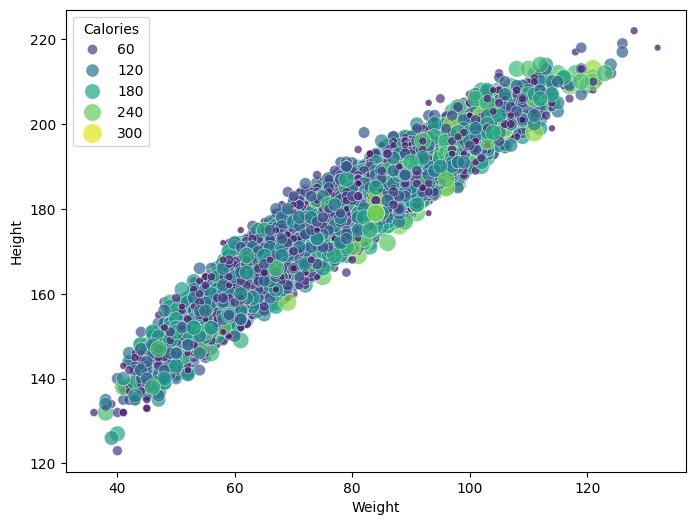

In [78]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='Weight',
    y='Height',
    size='Calories',
    hue='Calories',
    sizes=(20, 200),
    palette='viridis',
    alpha=0.7
)
plt.show()

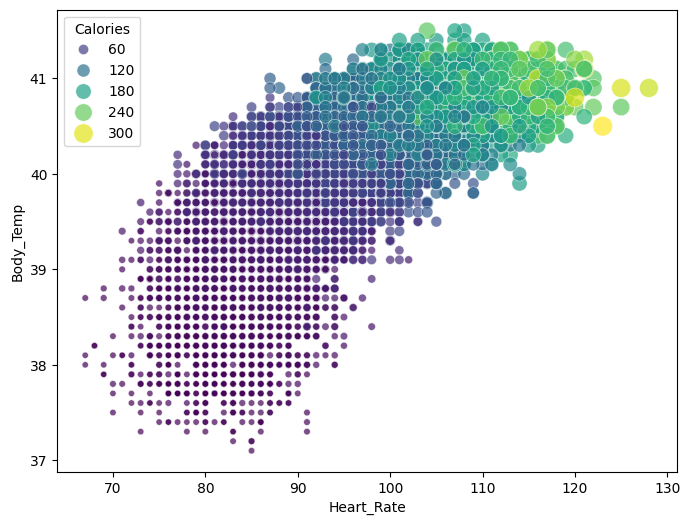

In [79]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='Heart_Rate',
    y='Body_Temp',
    size='Calories',
    hue='Calories',
    sizes=(20, 200),
    palette='viridis',
    alpha=0.7
)
plt.show()

<Figure size 1200x1000 with 0 Axes>

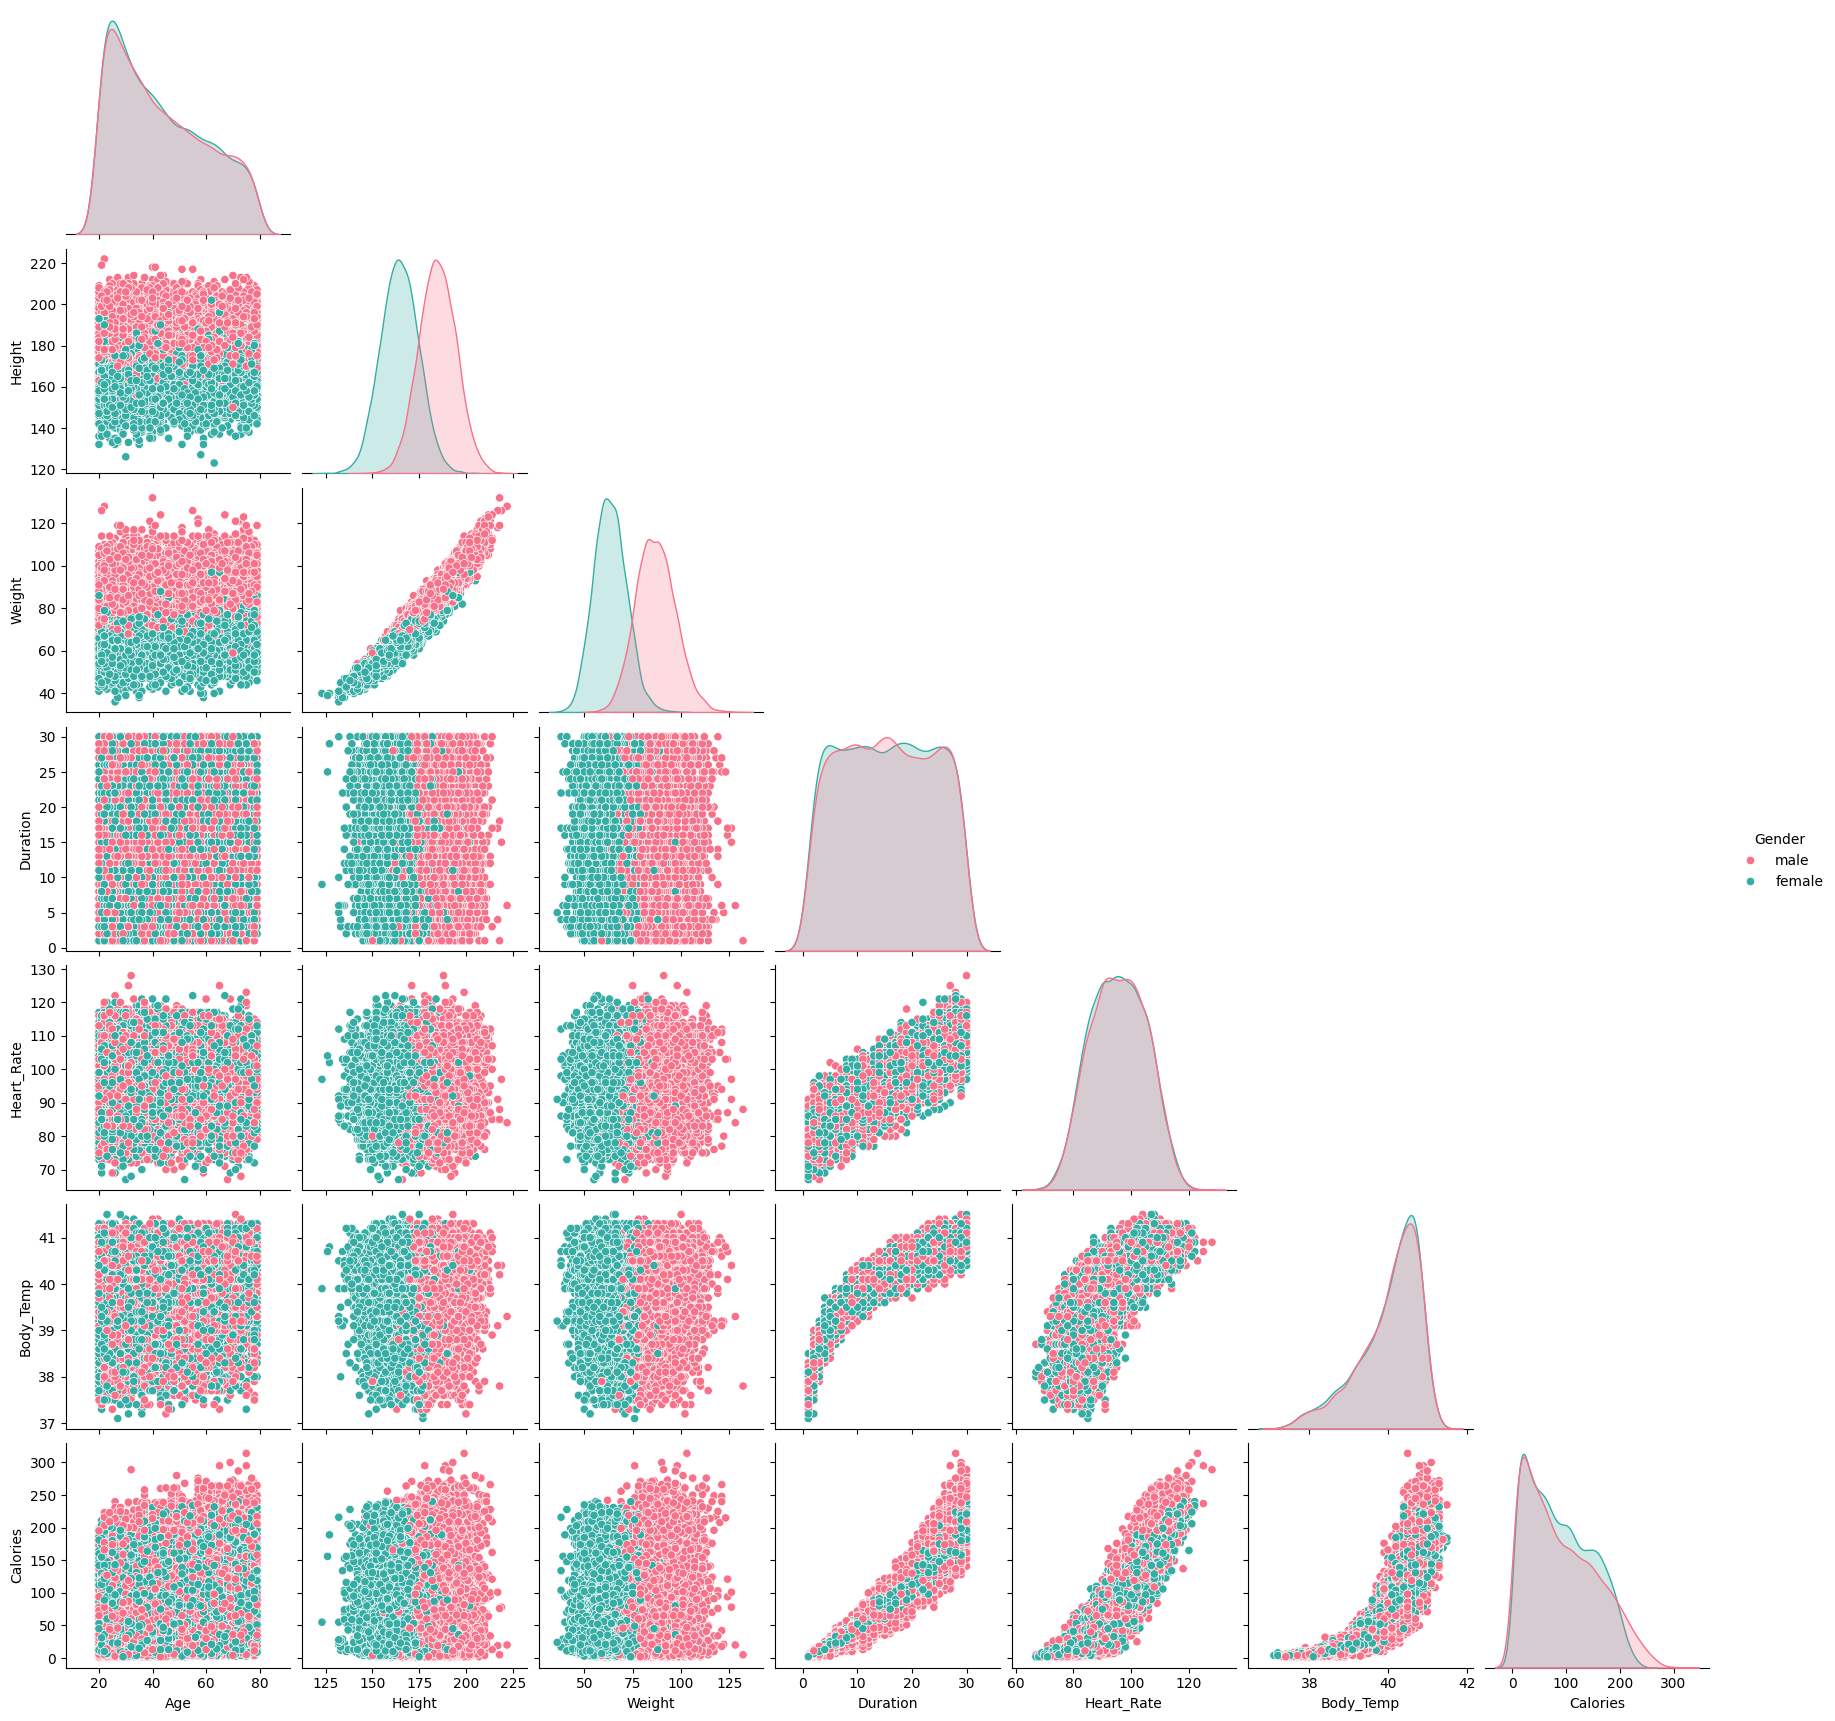

In [80]:
plt.figure(figsize=(12, 10))
sns.pairplot(df.drop(columns=['User_ID']), hue='Gender', palette='husl', diag_kind='kde', corner=True)

plt.show()

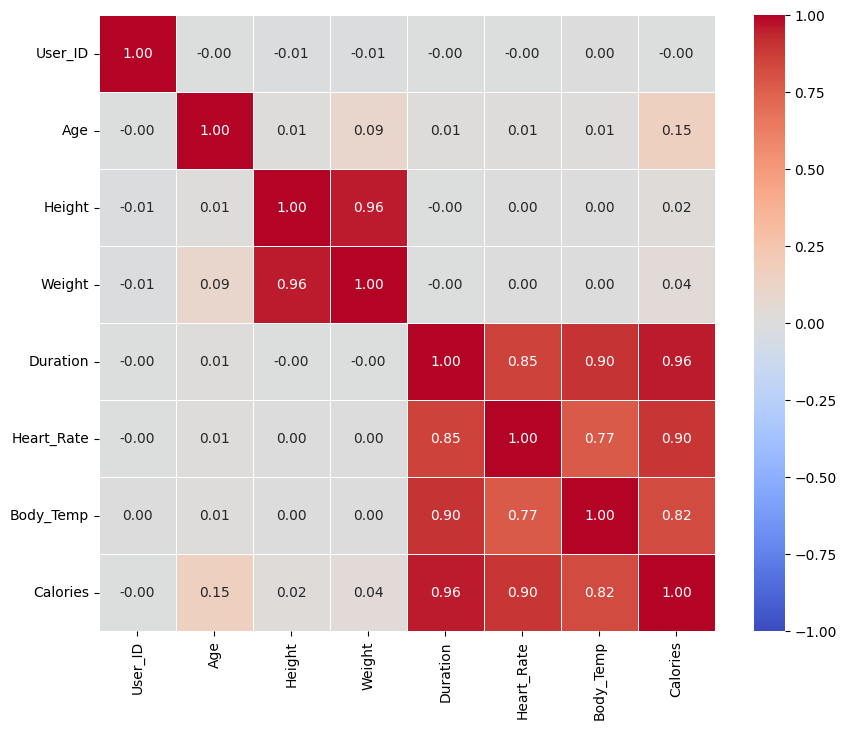

In [81]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            vmin=-1, vmax=1,
            linewidths=0.5,
            square=True)
plt.show()

#Preprocessing

In [82]:
X = df.drop(columns = ['User_ID', 'Calories'], axis=1)
y = df['Calories']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [83]:
le = LabelEncoder()
sc = StandardScaler()

X_train['Gender'] = le.fit_transform(X_train['Gender'])
X_val['Gender'] = le.transform(X_val['Gender'])
X_test['Gender'] = le.transform(X_test['Gender'])

In [84]:
df_train = pd.concat([X_train, y_train], axis=1)
df_val = pd.concat([X_val, y_val], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

df_train.to_csv('train.csv', index=False)
df_val.to_csv('val.csv', index=False)
df_test.to_csv('test.csv', index=False)